In [1]:
%pip install tensorflow==2.12.1

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [1]:
from tensorflow.keras.models import load_model
model = load_model("keras_model.h5")

In [2]:
model.compile()

In [3]:
import glob
imagens = glob.glob('*.jpg')
imagens

['PXL_20250801_231953752.jpg',
 'PXL_20250801_231949350.jpg',
 'PXL_20250801_231945848.jpg']

In [4]:
# Load class names from labels.txt
class_names = []
with open('labels.txt', 'r') as f:
    for line in f:
        index, name = line.strip().split(maxsplit=1)
        class_names.append(name)
class_names


['Caneta', 'Apagador', 'Nada']

PXL_20250801_231953752.jpg


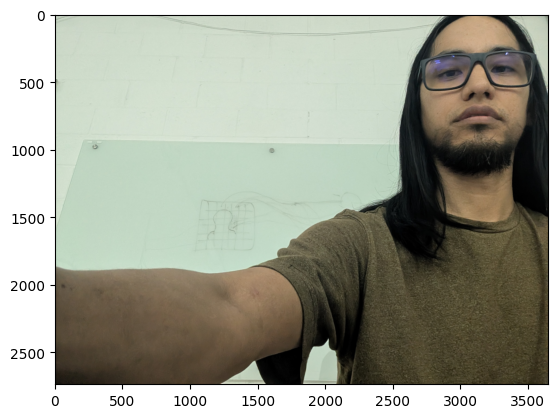

1/1 [==============================] - 1s 1s/step
Predições: [[5.2326318e-04 1.1963521e-04 9.9935716e-01]]
Predição: Nada
PXL_20250801_231949350.jpg


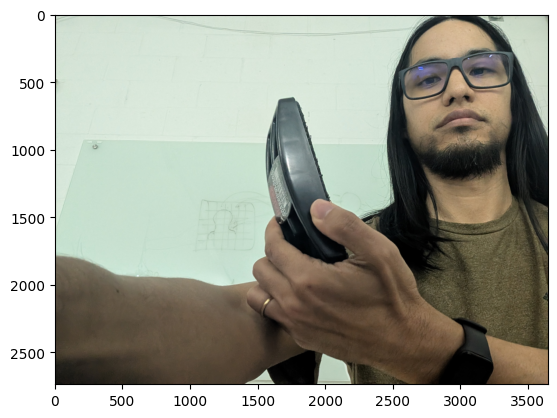

1/1 [==============================] - 0s 61ms/step
Predições: [[5.6052406e-04 5.8524536e-05 9.9938095e-01]]
Predição: Nada
PXL_20250801_231945848.jpg


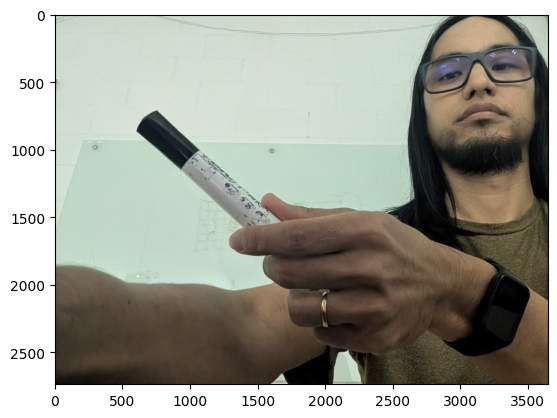

1/1 [==============================] - 0s 43ms/step
Predições: [[0.00573503 0.01016794 0.984097  ]]
Predição: Nada


In [5]:
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np


for caminho_imagem in imagens:
  # Mostrar a imagem e dados
  print(caminho_imagem)
  img = Image.open(caminho_imagem)
  plt.imshow(img)
  plt.show()

  # Load and preprocess the image
  img = image.load_img(caminho_imagem, target_size=(224, 224))
  img_array = image.img_to_array(img)
  img_array = img_array / 255.0  # normalize to [0, 1]
  img_array = np.expand_dims(img_array, axis=0)  # batch dimension

  # Predições
  predictions = model.predict(img_array)
  print("Predições:", predictions)
  print(f'Predição: {class_names[predictions.argmax()]}')